# **Laboratorio 4**

Integrantes del grupo
- Emmanuel Blanco - 202312743
- Juan David Guzmán - 202320890

### Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler

## **Carga de datos**

In [3]:
raw_data = pd.read_csv("Datos_VuelaAlpes.csv",sep=",")

print("Dimensiones de los datos")
print("Filas: ",raw_data.shape[0])
print("Columnas: ",raw_data.shape[1])

Dimensiones de los datos
Filas:  10000
Columnas:  23


## **Exploración de datos**

In [6]:
datos = raw_data.copy()

# Desplegamos el diccionario para entender que tipo de variables tenemos
diccionario = pd.read_excel("Diccionario VuelaAlpes.xlsx")
diccionario

,Variable,Tipo,Descripción
0,id,Entero,Identificador único del pasajero
1,Gender,Texto,Género del pasajero (Male / Female)
2,Customer Type,Texto,Tipo de cliente (Loyal Customer / disloyal Cus...
3,Age,Entero,Edad del pasajero
4,Type of Travel,Texto,Tipo de viaje (Business / Personal)
5,Class,Texto,"Clase del vuelo (Eco, Eco Plus, Business)"
6,Flight Distance,Entero,Distancia del vuelo
7,Inflight wifi service,Entero,Calificación del wifi (0–5)
8,Departure/Arrival time convenient,Entero,Conveniencia del horario (0–5)
9,Ease of Online booking,Entero,Facilidad de reserva online (0–5)


A primera vista podemos ver que la mayoría de las variables son categóricas, muchas de las variables representan una calificación de 0 a 5 en relación a un servicio.

Habiendo observado esto tenemos dos opciones, codificar las variables categóricas a números que el modelo sí pueda usar o hacer un modelamiento con alguna herramiento que permita manejar ambos tipos de variables

In [9]:
datos.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


In [10]:
# Revisamos los datos nulos

porcentajes_NaN = (datos.isnull().sum()/(datos.shape[0]*100)).sort_values(ascending=False)
info_faltante = pd.DataFrame({
    'Columna':porcentajes_NaN.index,
    'Total de datos faltantes':datos.isnull().sum()[porcentajes_NaN.index].values,
    '%':porcentajes_NaN.values
})
info_faltante[info_faltante['Total de datos faltantes']>0]

,Columna,Total de datos faltantes,%
0,Arrival Delay in Minutes,25,0.000025


Podemos ver que la variables Arrival Delay in minutes tiene filas vacías por lo que debemos completar esta columna

In [14]:
print(f"Registros duplicados: {datos.duplicated().sum()}")

Registros duplicados: 0


Revisaremos el formato de las entradas en Gender, Customer Type, Type of travel y Class

In [15]:
datos["Gender"].value_counts()

Gender
Female    5140
Male      4860
Name: count, dtype: int64

In [16]:
datos["Customer Type"].value_counts()

Customer Type
Loyal Customer       8155
disloyal Customer    1845
Name: count, dtype: int64

In [17]:
datos["Type of Travel"].value_counts()

Type of Travel
Business travel    6934
Personal Travel    3066
Name: count, dtype: int64

In [18]:
datos["Class"].value_counts()

Class
Business    4856
Eco         4442
Eco Plus     702
Name: count, dtype: int64

Revisamos la distribución de los datos de acuerdo a las variables

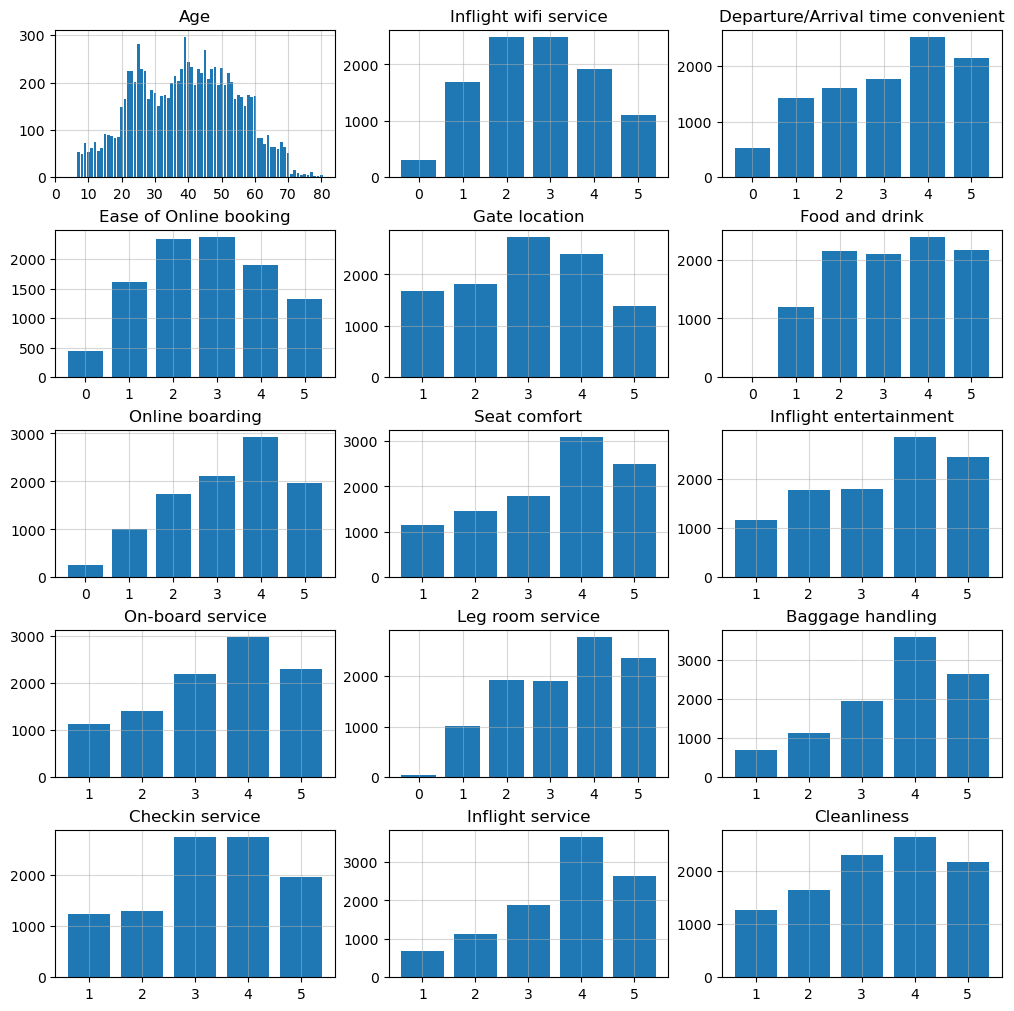

In [51]:
vars_hist = ["Flight Distance", "Departure Delay in Minutes"]
omitir = ["id","Flight Distance", "Departure Delay in Minutes","Arrival Delay in Minutes"]

vars_bar_plot = [
    col for col in datos.select_dtypes(include=[np.number]).columns
    if col not in omitir
]


fig, ax  = plt.subplots(5,3, layout="constrained",figsize=(10,10))

fila = 0
col = 0

for i in range(len(vars_bar_plot)):
    
    var = vars_bar_plot[i]
    counts = datos[var].value_counts()
    ax[fila][col].bar(counts.index,counts.values)
    ax[fila][col].grid(alpha=0.5)
    if var != "Age":
        ax[fila][col].set(title=var, xticks=counts.index)
    
    else:
        ax[fila][col].set(title=var, xticks= np.arange(0,81,10))
    
    if i == 2:
        fila = 1
        col = 0
    
    elif i == 5:
        fila = 2
        col = 0
    
    elif i == 8:
        fila = 3
        col = 0
        
    elif i == 11:
        fila = 4
        col = 0
    
    else:
        col+=1
        
plt.show()
    

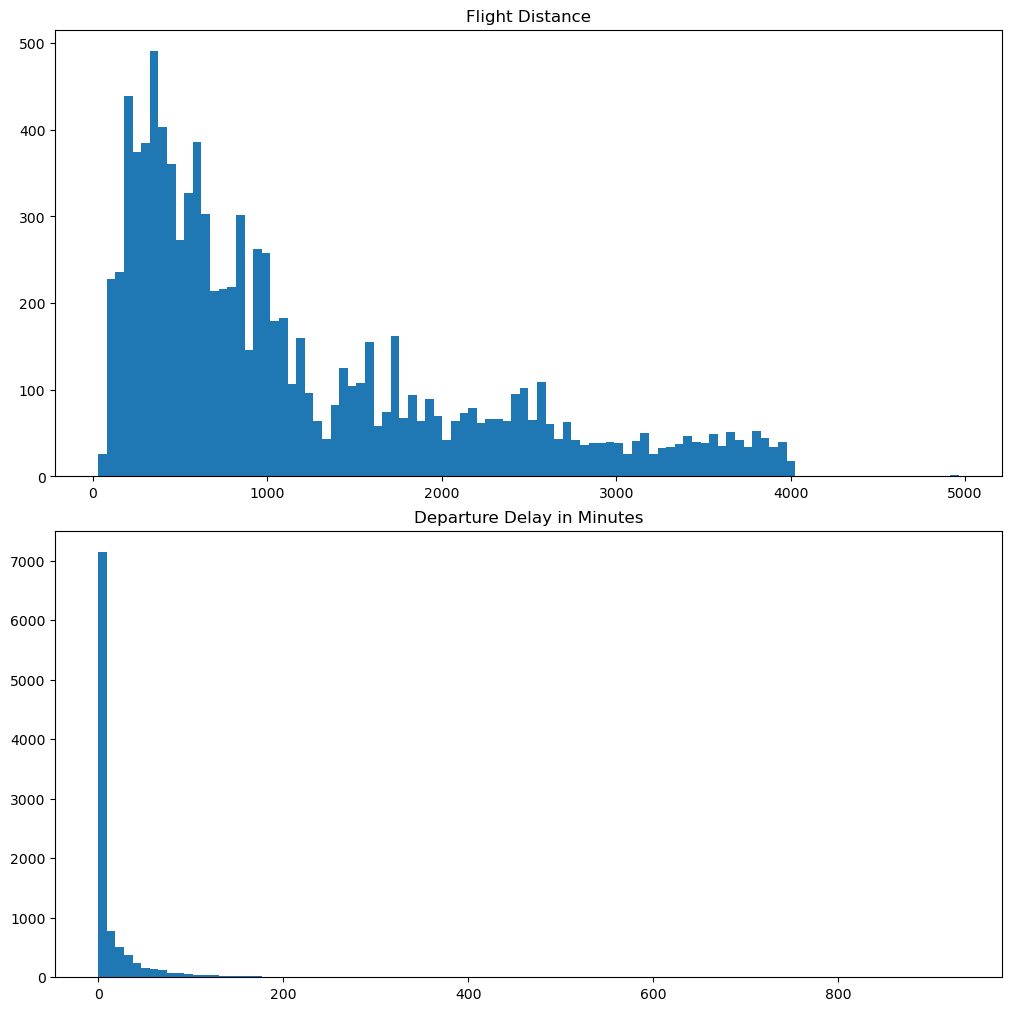

In [49]:
fig, ax  = plt.subplots(2,1, layout="constrained",figsize=(10,10))

for i in range(len(vars_hist)):
    var = vars_hist[i]
    counts, bin_edges = np.histogram(datos[var], bins=100)
    ax[i].stairs(counts, bin_edges, fill=True)
    ax[i].set(title=var)
    
plt.show()

## **Limpieza y Preparación de datos**

## **Modelamiento**

## **Análisis de resultados**

### **Evaluación cuantitativa**

### **Evaluación cualitativa**

## **Enlace al video explicativo de los resultados**

*enlace aquí*